In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import seaborn as sns

np.random.seed(42)
az.style.use('arviz-darkgrid')

In [2]:
data = pd.read_csv('data/IMDbMovies-Clean.csv')
data.head()

,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions)
0,Napoleon,An epic that details the checkered rise and fa...,Ridley Scott,David Scarpa,"Action,Adventure,Biography",R,2023.0,158.0,6.7,38.0,NaN,37.514,84.968,11.26.2023,20.639
1,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,2023.0,157.0,7.2,37.0,100.0,105.043,191.729,11.19.2023,44.607
2,The Killer,"After a fateful near-miss, an assassin battles...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent","Action,Adventure,Crime",R,2023.0,118.0,6.8,117.0,NaN,NaN,0.421,NaN,NaN
3,Leo,A 74-year-old lizard named Leo and his turtle ...,"David Wachtenheim,Robert Smigel,Robert Marianetti","Paul Sado,Robert Smigel,Adam Sandler","Animation,Comedy,Family",PG,2023.0,102.0,7.0,10.0,NaN,NaN,NaN,NaN,NaN
4,Thanksgiving,"After a Black Friday riot ends in tragedy, a m...",Eli Roth,"Eli Roth,Jeff Rendell","Horror,Mystery,Thriller",R,2023.0,106.0,7.0,9.1,NaN,25.409,29.667,11.19.2023,10.306


In [3]:
df_clean = data[['Title', 'Main Genres', 'Motion Picture Rating', 'Rating (Out of 10)', 'Number of Ratings (in thousands)', 'Budget (in millions)', 'Gross worldwide (in millions)']].dropna()
df_clean = df_clean[df_clean['Motion Picture Rating'].isin(['R', 'PG-13'])].copy()
df_clean['is_pg13'] = (df_clean['Motion Picture Rating'] == 'PG-13').astype(int)

dark_genres = 'Action|Horror|Thriller'
df_clean['is_dark_genre'] = df_clean['Main Genres'].str.contains(dark_genres).astype(int)

df_clean = df_clean[(df_clean['Budget (in millions)'] > 0) & (df_clean['Gross worldwide (in millions)'] > 0)]

df_clean['log_budget'] = np.log(df_clean['Budget (in millions)'])
df_clean['std_budget'] = (df_clean['log_budget'] - df_clean['log_budget'].mean()) / df_clean['log_budget'].std()

df_clean['log_gross'] = np.log(df_clean['Gross worldwide (in millions)'])
df_clean['std_gross'] = (df_clean['log_gross'] - df_clean['log_gross'].mean()) / df_clean['log_gross'].std()
df_clean['weighted_rating'] = df_clean['Rating (Out of 10)'] / np.sqrt(df_clean['Number of Ratings (in thousands)'])

rating_data_baseline = {
    "N": len(df_clean),
    "y": df_clean["Rating (Out of 10)"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values,
    "num_ratings": df_clean["Number of Ratings (in thousands)"].values
}
rating_data_extended = {
    "N": len(df_clean),
    "y": df_clean["Rating (Out of 10)"].values,
    "is_pg13": df_clean["is_pg13"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values,
    "num_ratings": df_clean["Number of Ratings (in thousands)"].values
}
revenue_data_baseline = {
    "N": len(df_clean),
    "y": df_clean["std_gross"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}
revenue_data_extended = {
    "N": len(df_clean),
    "y": df_clean["std_gross"].values,
    "is_pg13": df_clean["is_pg13"].values,
    "is_dark_genre": df_clean["is_dark_genre"].values,
    "budget": df_clean["std_budget"].values
}

### Prior Predictive Check

/tmp/ipykernel_12534/3232363642.py:111: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


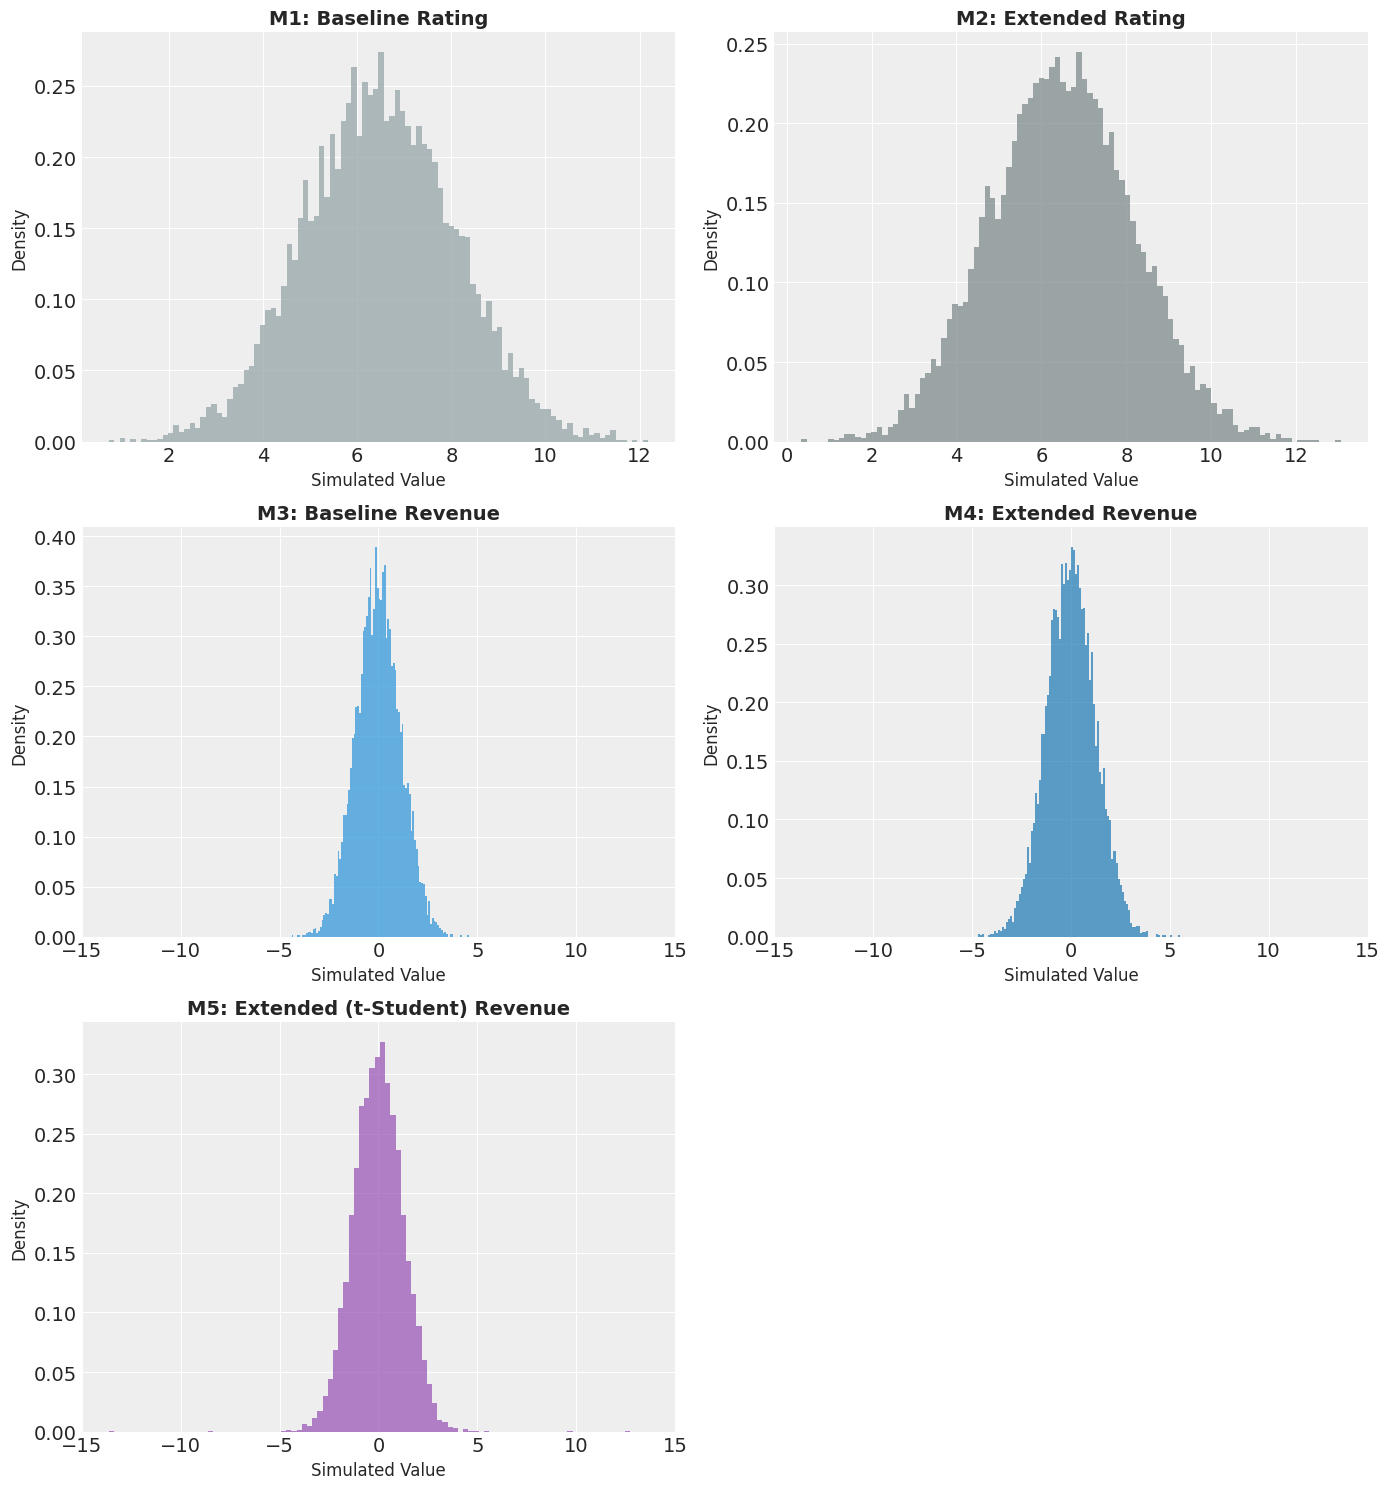

In [4]:
N_samples = 10000
num_movies = len(df_clean)

is_pg13 = df_clean['is_pg13'].values
is_dark = df_clean['is_dark_genre'].values
budget = df_clean['std_budget'].values
num_ratings = df_clean['Number of Ratings (in thousands)'].values

prior_plots = {'M1': [], 'M2': [], 'M3': [], 'M4': [], 'M5': []}

for _ in range(N_samples):
    # --- PRIORY DLA OCEN (RATING TRACK) ---
    alpha_r = np.random.normal(6.5, 1.5)
    b_dark_r = np.random.normal(0, 1)
    b_pg13_r = np.random.normal(0, 1)
    b_budget_r = np.random.normal(0, 1)
    b_pg13_dark_r = np.random.normal(0, 1)
    b_pg13_budget_r = np.random.normal(0, 1)
    b_dark_budget_r = np.random.normal(0, 1)
    b_triple_r = np.random.normal(0, 1)
    sigma_r = np.random.exponential(1)
    
    # NOWOŚĆ: Obliczamy zwagowane odchylenie standardowe dla każdego filmu osobno
    # Dodajemy 0.001, aby zabezpieczyć się przed dzieleniem przez zero
    weighted_sigma_r = sigma_r / np.sqrt(num_ratings + 0.001)
    
    # --- PRIORY DLA PRZYCHODÓW (REVENUE TRACK) ---
    alpha_v = np.random.normal(0, 1)
    b_dark_v = np.random.normal(0, 1)
    b_pg13_v = np.random.normal(0, 1)
    
    # MODYFIKACJA: Silny, dodatni prior dla budżetu odzwierciedlający intuicję ekonomiczną
    b_budget_v = np.random.normal(0.7, 0.2) 
    
    b_pg13_dark_v = np.random.normal(0, 1)
    b_pg13_budget_v = np.random.normal(0, 1)
    b_dark_budget_v = np.random.normal(0, 1)
    b_triple_v = np.random.normal(0, 1)
    sigma_v = np.random.exponential(1)
    nu_v = np.random.gamma(2, 1/0.1)
    
    # ----------------------------------------------------
    # SYMULACJE MODELI (Z ZASTOSOWANIEM WAG DLA OCEN M1 I M2)
    # ----------------------------------------------------
    
    # M1: Baseline Rating (Z wagami)
    mu_m1 = alpha_r + b_dark_r * is_dark + b_budget_r * budget
    # Przekazujemy wektor indywidualnych odchyleń standardowych do np.random.normal
    y_m1 = np.random.normal(mu_m1, weighted_sigma_r)
    prior_plots['M1'].append(np.mean(y_m1))
    
    # M2: Extended Rating (Z wagami)
    mu_m2 = (alpha_r + b_pg13_r * is_pg13 + b_dark_r * is_dark + b_budget_r * budget +
             b_pg13_dark_r * (is_pg13 * is_dark) +
             b_pg13_budget_r * (is_pg13 * budget) +
             b_dark_budget_r * (is_dark * budget) +
             b_triple_r * (is_pg13 * is_dark * budget))
    y_m2 = np.random.normal(mu_m2, weighted_sigma_r)
    prior_plots['M2'].append(np.mean(y_m2))
    
    # M3: Baseline Revenue (Zostaje klasyczny, bo przychody nie zależą od liczby ocen na IMDb)
    mu_m3 = alpha_v + b_dark_v * is_dark + b_budget_v * budget
    y_m3 = np.random.normal(mu_m3, sigma_v)
    prior_plots['M3'].append(np.mean(y_m3))
    
    # M4: Extended Revenue (Gauss)
    mu_m4 = (alpha_v + b_pg13_v * is_pg13 + b_dark_v * is_dark + b_budget_v * budget +
             b_pg13_dark_v * (is_pg13 * is_dark) +
             b_pg13_budget_v * (is_pg13 * budget) +
             b_dark_budget_v * (is_dark * budget) +
             b_triple_v * (is_pg13 * is_dark * budget))
    y_m4 = np.random.normal(mu_m4, sigma_v)
    prior_plots['M4'].append(np.mean(y_m4))
    
    # M5: Extended Revenue (Student-t)
    y_m5 = mu_m4 + np.random.standard_t(nu_v, size=num_movies) * sigma_v
    prior_plots['M5'].append(np.mean(y_m5))

for key in prior_plots:
    prior_plots[key] = np.array(prior_plots[key])


fig, axes = plt.subplots(3, 2, figsize=(14, 15))
az.style.use('arviz-darkgrid')

titles = [
    "M1: Baseline Rating", "M2: Extended Rating",
    "M3: Baseline Revenue", "M4: Extended Revenue",
    "M5: Extended (t-Student) Revenue"
]
keys = ['M1', 'M2', 'M3', 'M4', 'M5']
colors = ['#95a5a6', '#7f8c8d', '#3498db', '#2980b9', '#9b59b6']

for i, ax in enumerate(axes.flat[:5]):
    current_data = prior_plots[keys[i]]
    
    # Filter outliers for the t-Student model (M5) to improve visualization (since t-Student can produce extreme values)
    if keys[i] == 'M5':
        current_data = current_data[(current_data > -15) & (current_data < 15)]
        
    ax.hist(current_data, bins=100, color=colors[i], density=True, alpha=0.75, edgecolor='none')
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("Simulated Value", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    
    if keys[i] in ['M3', 'M4', 'M5']:
        ax.set_xlim(-15, 15)

axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_12534/1924388738.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


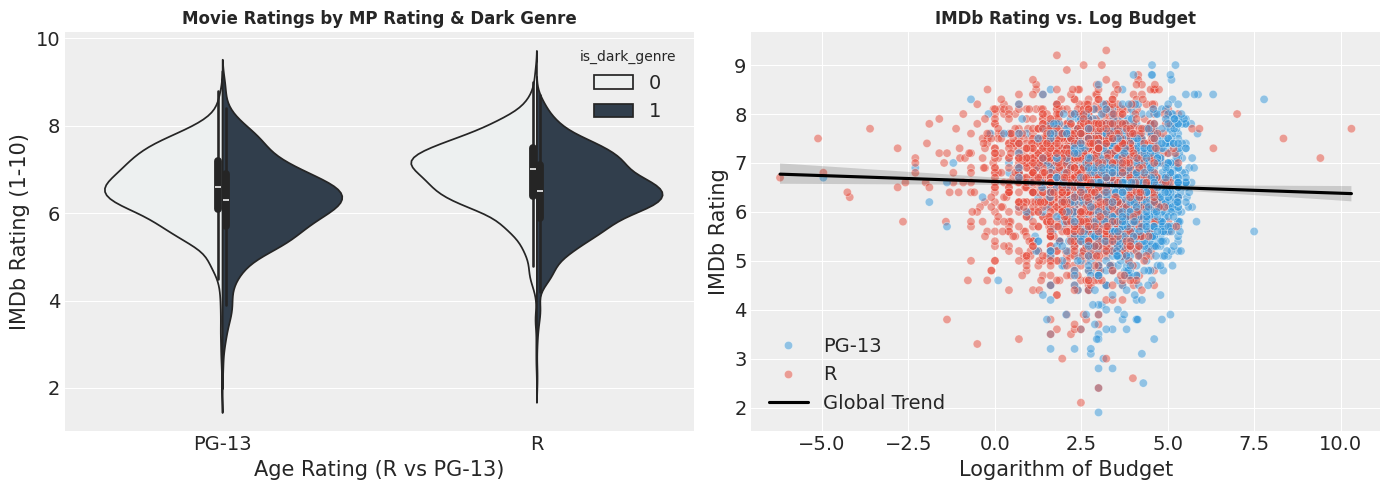

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df_clean, 
    x='Motion Picture Rating', 
    y='Rating (Out of 10)', 
    hue='is_dark_genre',
    split=True,
    palette={1: '#2c3e50', 0: '#ecf0f1'},
    ax=axes[0]
)
axes[0].set_title("Movie Ratings by MP Rating & Dark Genre", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Age Rating (R vs PG-13)")
axes[0].set_ylabel("IMDb Rating (1-10)")

# 2. Korelacja budżetu z oceną
sns.scatterplot(
    data=df_clean, 
    x='log_budget', 
    y='Rating (Out of 10)', 
    hue='Motion Picture Rating',
    alpha=0.5,
    palette={'R': '#e74c3c', 'PG-13': '#3498db'},
    ax=axes[1]
)
# Dodanie linii trendu, żeby zobaczyć czy relacja w ogóle istnieje
sns.regplot(data=df_clean, x='log_budget', y='Rating (Out of 10)', scatter=False, ax=axes[1], color='black', label='Global Trend')
axes[1].set_title("IMDb Rating vs. Log Budget", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Logarithm of Budget")
axes[1].set_ylabel("IMDb Rating")
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_12534/1495129780.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


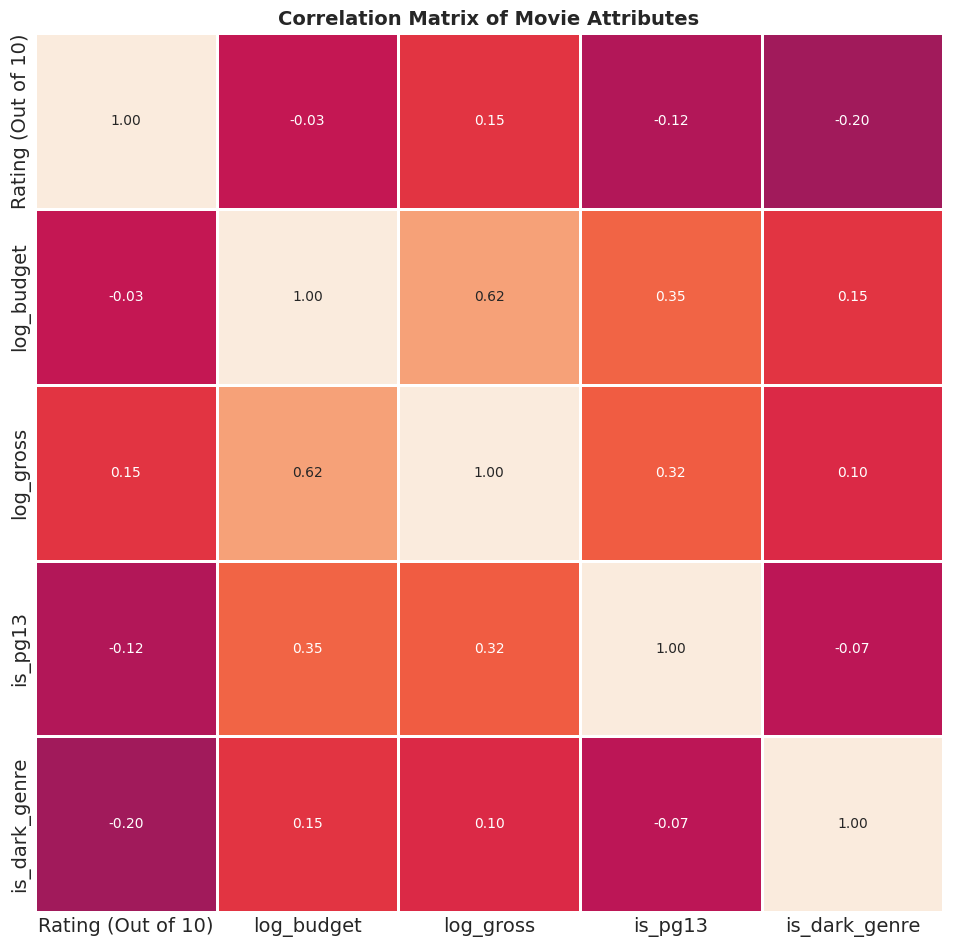

In [6]:
plt.figure(figsize=(12, 12))

# Wybieramy kluczowe kolumny do korelacji
corr_matrix = df_clean[['Rating (Out of 10)', 'log_budget', 'log_gross', 'is_pg13', 'is_dark_genre']].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    linewidths=.8,
    vmin=-1, vmax=1,
    cbar=False
)
plt.title("Correlation Matrix of Movie Attributes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 900x600 with 0 Axes>

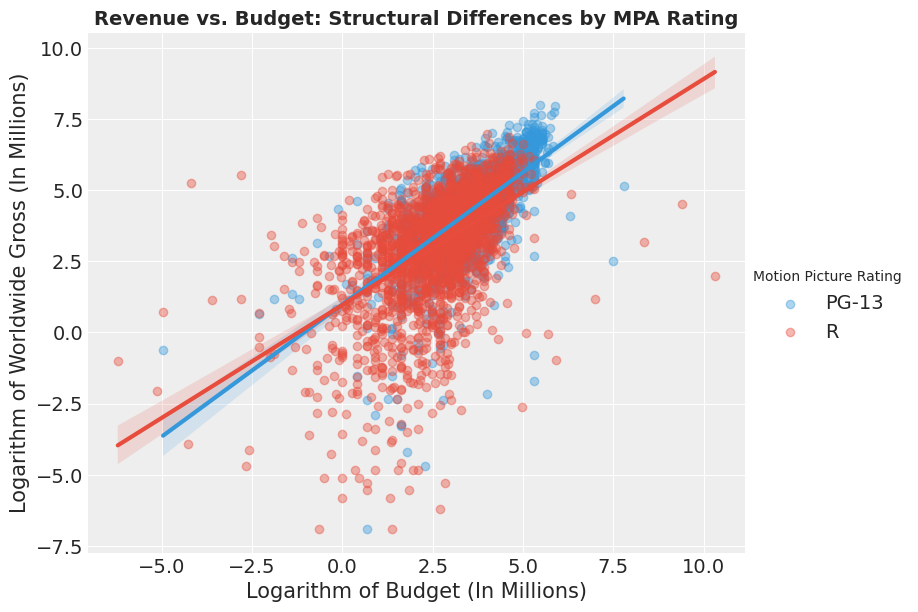

In [7]:
plt.figure(figsize=(9, 6))

# Rysujemy punkty i osobne linie trendu OLS dla każdej kategorii wiekowej
sns.lmplot(
    data=df_clean, 
    x='log_budget', 
    y='log_gross', 
    hue='Motion Picture Rating',
    palette={'R': '#e74c3c', 'PG-13': '#3498db'},
    scatter_kws={'alpha': 0.4},
    line_kws={'lw': 3},
    height=6, 
    aspect=1.3
)

plt.title("Revenue vs. Budget: Structural Differences by MPA Rating", fontsize=14, fontweight='bold')
plt.xlabel("Logarithm of Budget (In Millions)")
plt.ylabel("Logarithm of Worldwide Gross (In Millions)")
plt.show()

In [8]:
model1_baseline_rating = CmdStanModel(stan_file='stan/model1_baseline_rating.stan')
model1_extended_rating = CmdStanModel(stan_file='stan/model1_extended_rating.stan')
model_student_rating = CmdStanModel(stan_file='stan/model_student_rating.stan')

model1_baseline_revenue = CmdStanModel(stan_file='stan/model1_baseline_revenue.stan')
model1_extended_revenue = CmdStanModel(stan_file='stan/model1_extended_revenue.stan')
model2_extended_revenue = CmdStanModel(
    stan_file='stan/model_student.stan',
)


## Rating analysis

#### Fit models

In [9]:
fit_model1_baseline_rating = model1_baseline_rating.sample(data=rating_data_baseline, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model1_extended_rating = model1_extended_rating.sample(data=rating_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model_student_rating = model_student_rating.sample(data=rating_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

15:41:07 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:42:14 - cmdstanpy - INFO - CmdStan done processing.
15:42:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_student_rating.stan', line 54, column 2 to column 40)
	Exception: student_t_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_student_rating.stan', line 54, column 2 to column 40)
	Exception: student_t_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_student_rating.stan', line 54, column 2 to column 40)
	Exception: student_t_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_student_rating.stan', line 54, column 2 to column 40)
	Exception: student_t_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_student_rating.stan', line 54, column 2 to column 40)
Exception: student_t_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_student_rating.stan', line 54, column 2 t

#### Compare with `az`

In [10]:
idata_model1_baseline_rating = az.from_cmdstanpy(fit_model1_baseline_rating)
idata_model1_extended_rating = az.from_cmdstanpy(fit_model1_extended_rating)
idata_model_student_rating = az.from_cmdstanpy(fit_model_student_rating)

                             rank     elpd_loo      p_loo   elpd_diff  \
Student model                   0 -5782.661640  18.089837    0.000000   
Extended model (With PG-13)     1 -6411.827043  33.030097  629.165402   
Base Model (Without PG-13)      2 -6496.392759  20.059787  713.731118   

                               weight         se        dse  warning scale  
Student model                0.806195  62.056092   0.000000    False   log  
Extended model (With PG-13)  0.124810  95.289658  72.230670    False   log  
Base Model (Without PG-13)   0.068996  95.817461  72.792656    False   log  


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

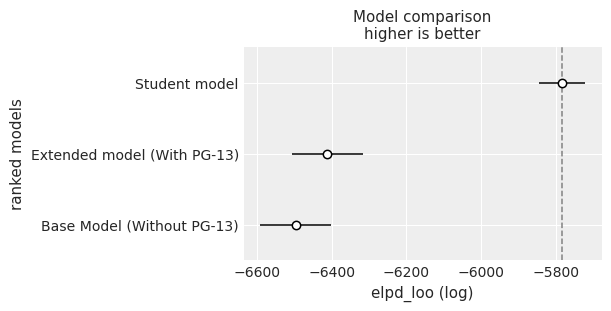

In [11]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_rating, "Extended model (With PG-13)": idata_model1_extended_rating, "Student model": idata_model_student_rating}, ic="loo")
print(comp)

az.plot_compare(comp)

#### Analyze

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

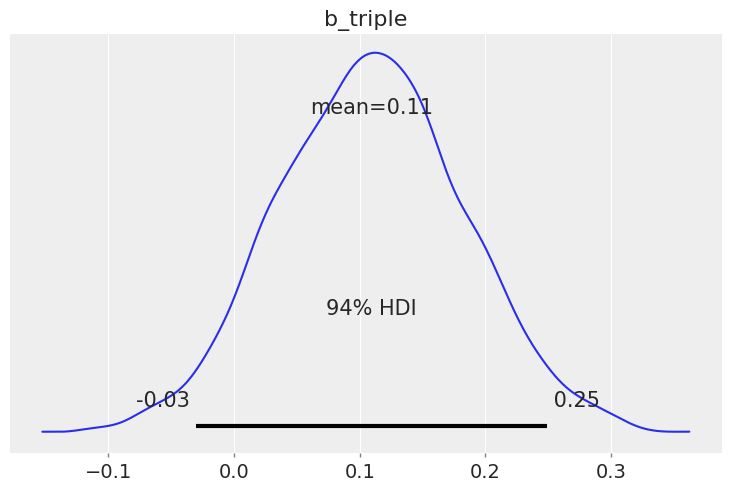

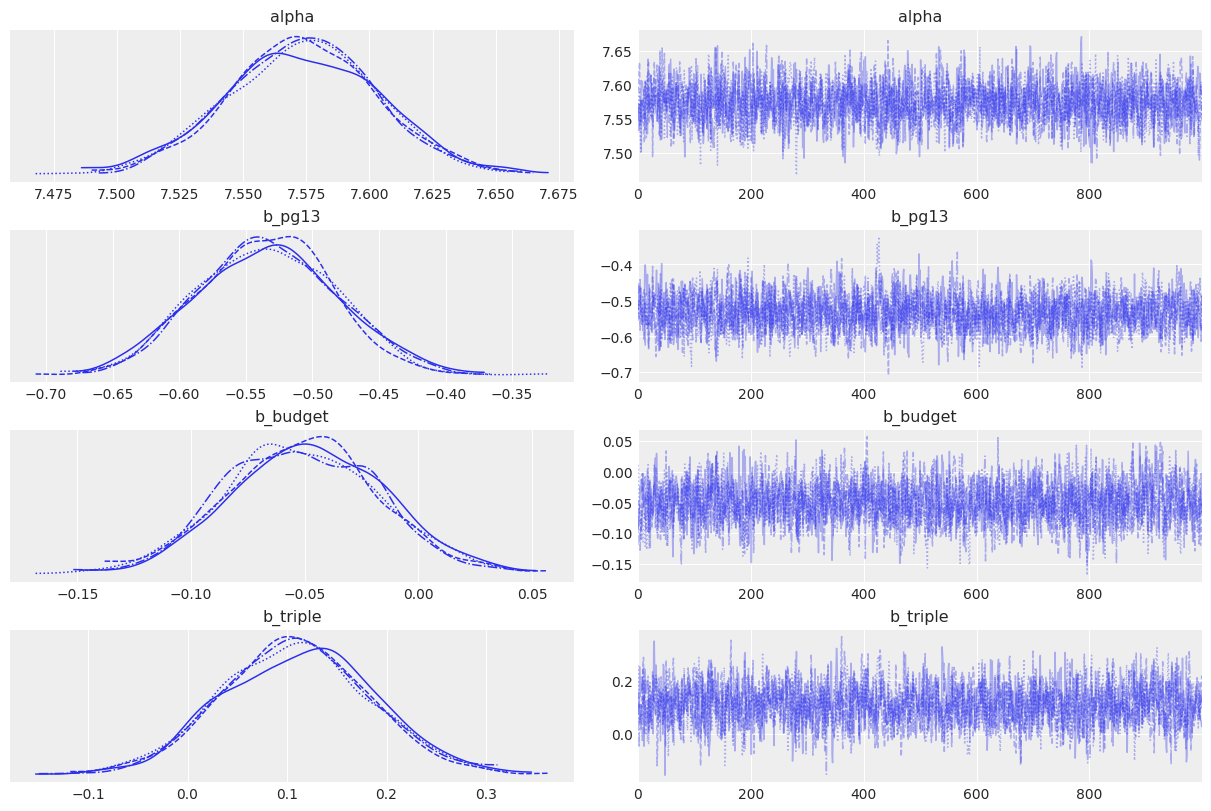

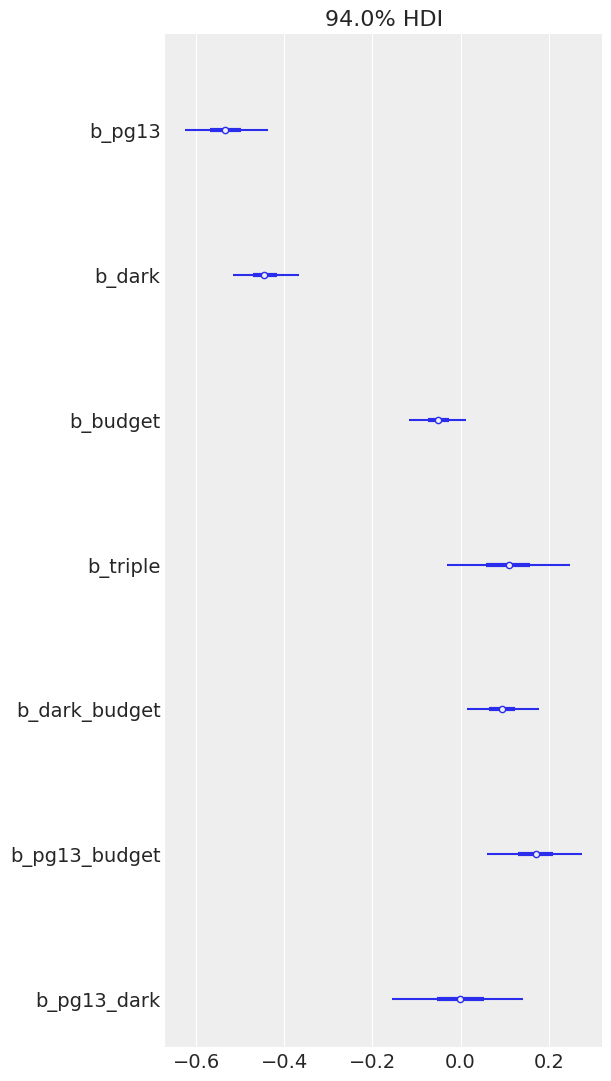

In [12]:
az.plot_posterior(idata_model1_extended_rating, var_names=['b_triple'])
az.plot_trace(idata_model1_extended_rating, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model1_extended_rating, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

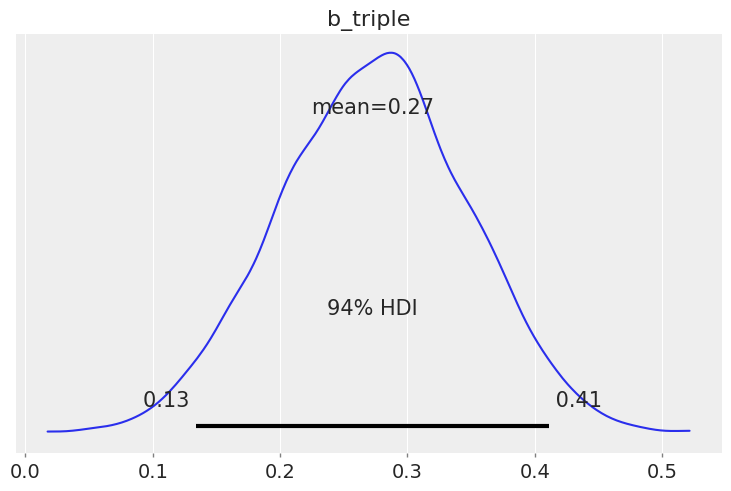

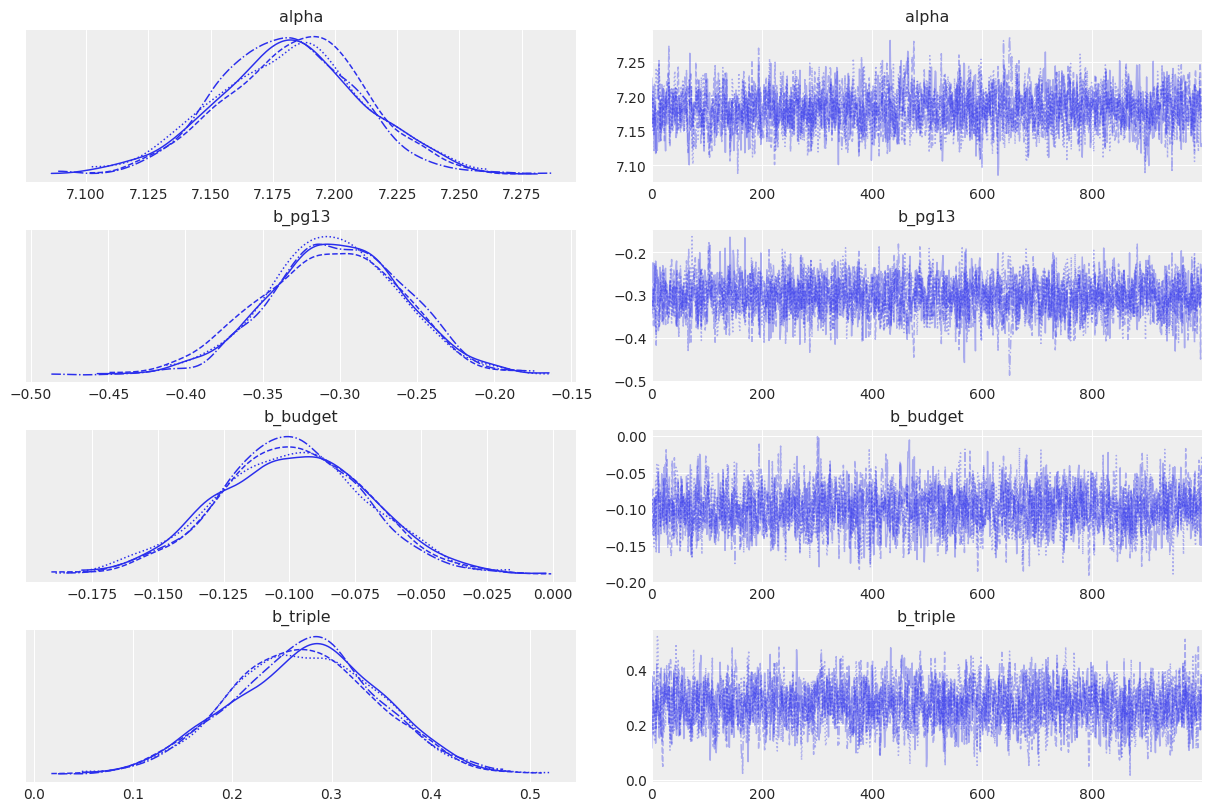

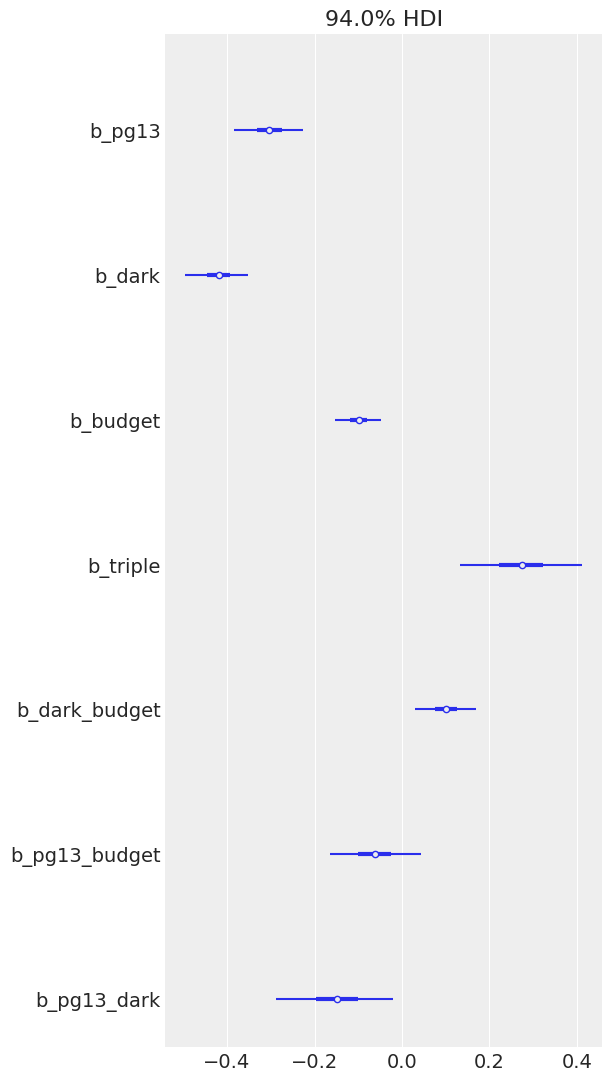

In [13]:
az.plot_posterior(idata_model_student_rating, var_names=['b_triple'])
az.plot_trace(idata_model_student_rating, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model_student_rating, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

#### Posterior predictive distribution

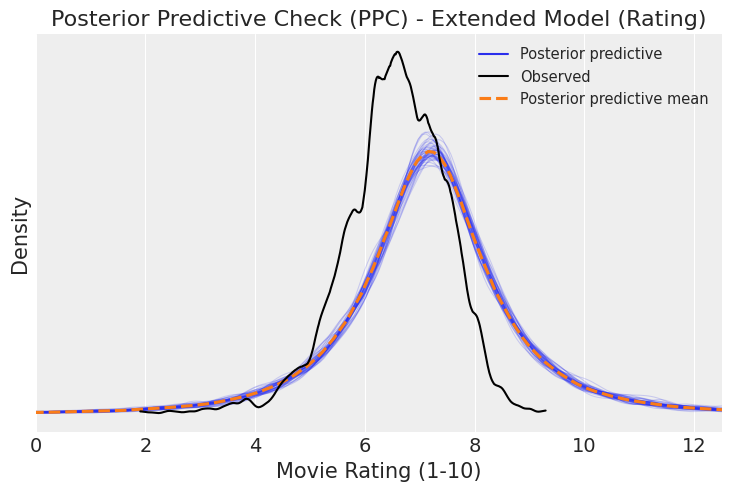

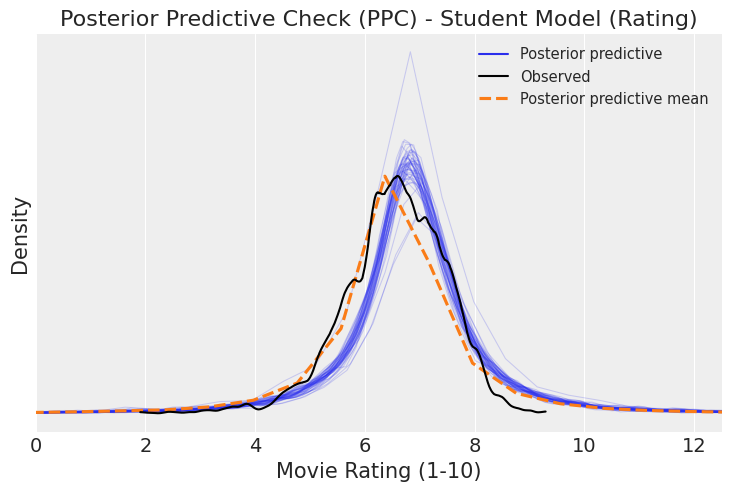

In [14]:

idata_extended_rating = az.from_cmdstanpy(
    posterior=fit_model1_extended_rating,
    posterior_predictive="y_rep",
observed_data={"y": df_clean["Rating (Out of 10)"].values})

az.plot_ppc(idata_extended_rating, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")
plt.xlim(0, 12.5)
plt.title("Posterior Predictive Check (PPC) - Extended Model (Rating)")
plt.xlabel("Movie Rating (1-10)")
plt.ylabel("Density")
plt.show()


idata_student_rating = az.from_cmdstanpy(
    posterior=fit_model_student_rating,
    posterior_predictive="y_rep",
observed_data={"y": df_clean["Rating (Out of 10)"].values})

az.plot_ppc(idata_student_rating, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")
plt.xlim(0, 12.5)
plt.title("Posterior Predictive Check (PPC) - Student Model (Rating)")
plt.xlabel("Movie Rating (1-10)")
plt.ylabel("Density")
plt.show()

## Revenue analysis

#### Fit models

In [15]:
fit_model1_baseline_revenue = model1_baseline_revenue.sample(data=revenue_data_baseline, chains=4, iter_sampling=1000, parallel_chains=4)
fit_model1_extended_revenue = model1_extended_revenue.sample(data=revenue_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

15:43:01 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:43:20 - cmdstanpy - INFO - CmdStan done processing.
15:43:20 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_extended_revenue.stan', line 36, column 2 to column 24)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_extended_revenue.stan', line 36, column 2 to column 24)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_extended_revenue.stan', line 36, column 2 to column 24)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_extended_revenue.stan', line 36, column 2 to column 24)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_extended_revenue.stan', line 36, column 2 to column 24)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_extended_revenue.stan', line 36, column 2 to column 24)
	Exception: normal_lpdf: Scale parameter is 0, but must be p

#### Compare with `az`

In [16]:
idata_model1_baseline_revenue = az.from_cmdstanpy(fit_model1_baseline_revenue)
idata_model1_extended_revenue = az.from_cmdstanpy(fit_model1_extended_revenue)

                             rank     elpd_loo      p_loo  elpd_diff  \
Extended model (With PG-13)     0 -4538.767761  15.525651   0.000000   
Base Model (Without PG-13)      1 -4576.887097   9.936743  38.119336   

                               weight         se       dse  warning scale  
Extended model (With PG-13)  0.968409  81.804585  0.000000    False   log  
Base Model (Without PG-13)   0.031591  82.391188  9.470137    False   log  


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

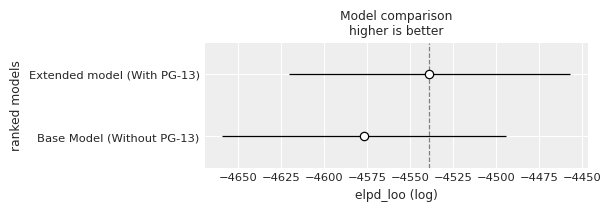

In [17]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (With PG-13)": idata_model1_extended_revenue}, ic="loo")
print(comp)

az.plot_compare(comp)

/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


                             rank    elpd_waic     p_waic  elpd_diff  \
Extended model (With PG-13)     0 -4538.740049  15.497939   0.000000   
Base Model (Without PG-13)      1 -4576.881657   9.931303  38.141609   

                               weight         se       dse  warning scale  
Extended model (With PG-13)  0.968572  81.802594  0.000000     True   log  
Base Model (Without PG-13)   0.031428  82.391252  9.472554     True   log  


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

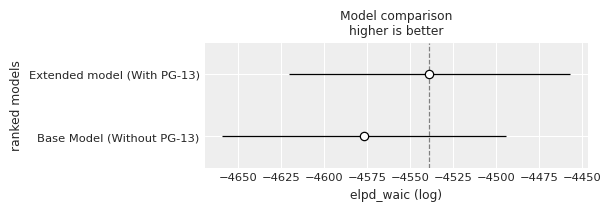

In [18]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (With PG-13)": idata_model1_extended_revenue}, ic="waic")
print(comp)

az.plot_compare(comp)

#### Analyze

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

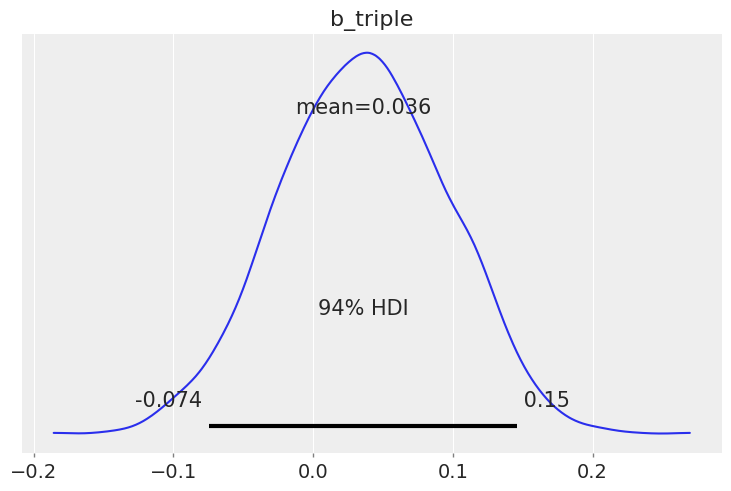

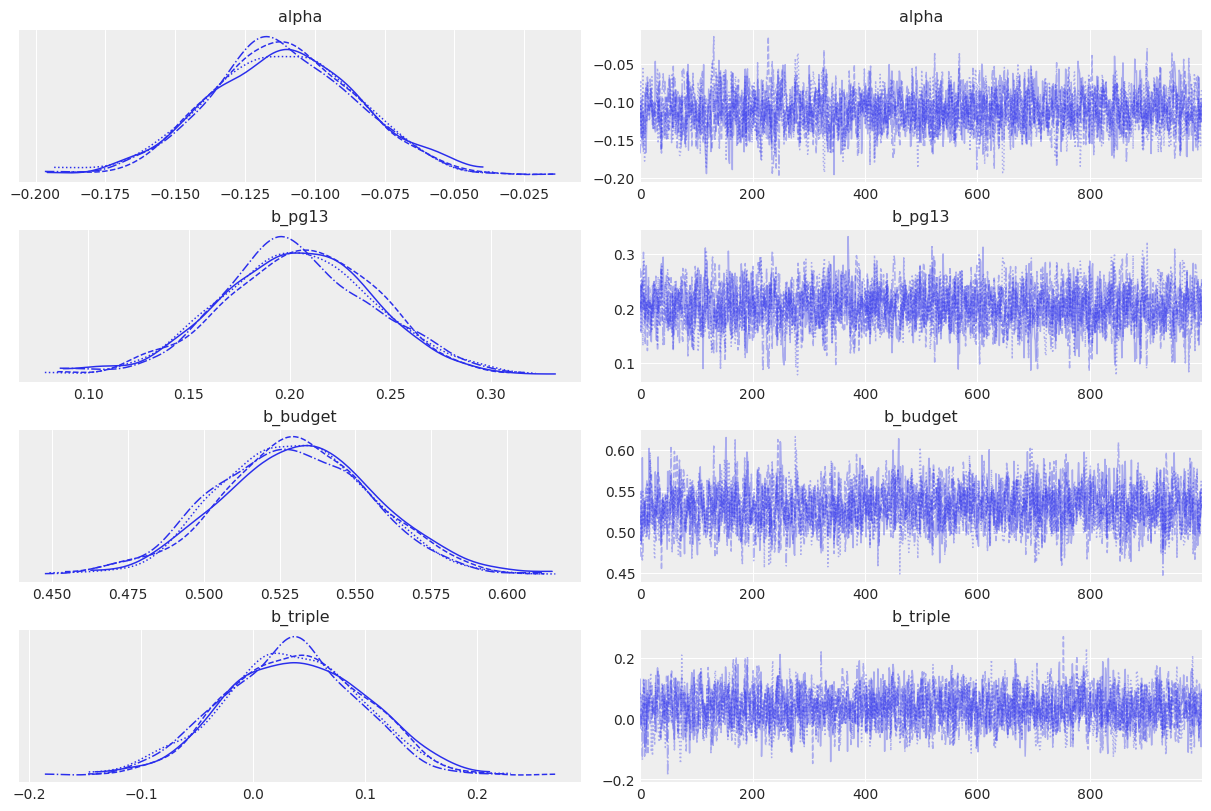

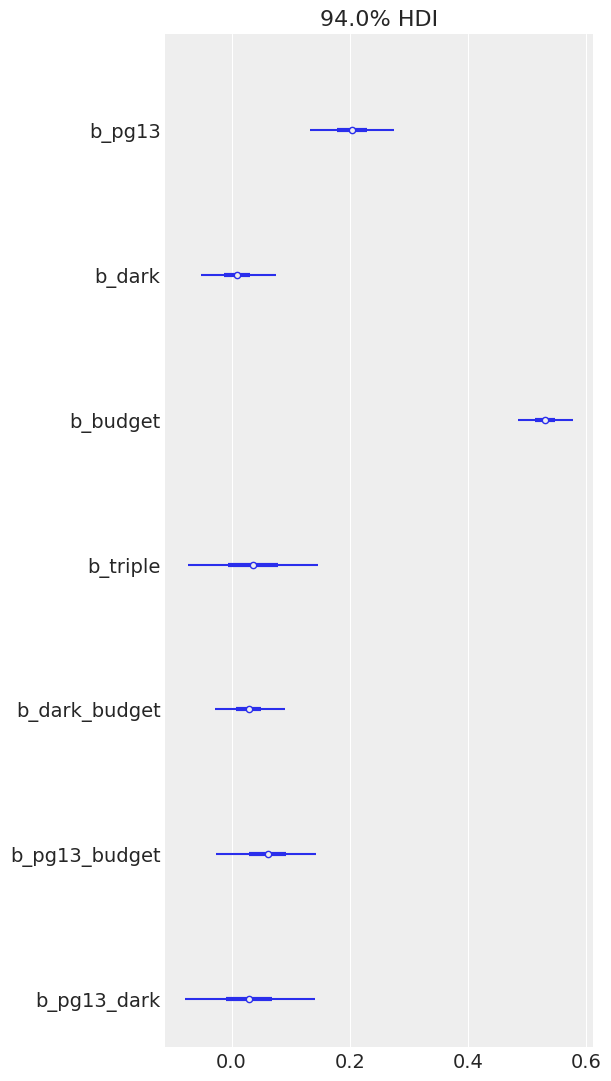

In [19]:
az.plot_posterior(idata_model1_extended_revenue, var_names=['b_triple'])
az.plot_trace(idata_model1_extended_revenue, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model1_extended_revenue, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

#### Posterior predictive distribution

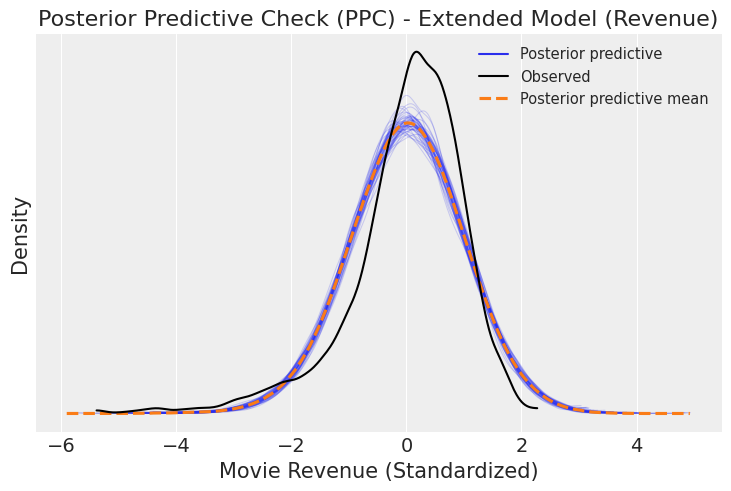

In [20]:
idata_extended_revenue = az.from_cmdstanpy(
    posterior=fit_model1_extended_revenue,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["std_gross"].values}
)

az.plot_ppc(idata_extended_revenue, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Revenue)")
plt.xlabel("Movie Revenue (Standardized)")
plt.ylabel("Density")
plt.show()

## Model 2 (Student's T distribution)

In [21]:
fit_model2_extended_revenue = model2_extended_revenue.sample(data=revenue_data_extended, chains=4, iter_sampling=1000, parallel_chains=4)

15:43:40 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:44:34 - cmdstanpy - INFO - CmdStan done processing.
15:44:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'model_student.stan', line 22, column 2 to column 21)
Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_student.stan', line 33, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_student.stan', line 33, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_student.stan', line 33, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_student.stan', line 33, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_student.stan', line 33, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but 

In [22]:
idata_model2_extended_revenue = az.from_cmdstanpy(fit_model2_extended_revenue)

                                         rank     elpd_loo      p_loo  \
Extended model (Student-t) (With PG-13)     0 -4142.630126  12.648603   
Base Model (Without PG-13)                  1 -4576.887097   9.936743   

                                          elpd_diff    weight         se  \
Extended model (Student-t) (With PG-13)    0.000000  0.953936  66.110833   
Base Model (Without PG-13)               434.256971  0.046064  82.391188   

                                               dse  warning scale  
Extended model (Student-t) (With PG-13)   0.000000    False   log  
Base Model (Without PG-13)               43.219525    False   log  


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

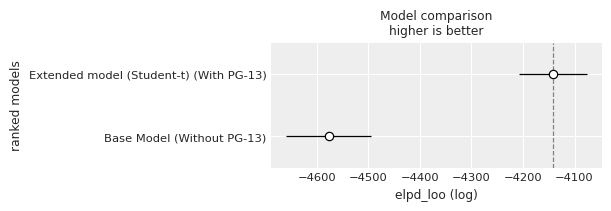

In [23]:
comp = az.compare({"Base Model (Without PG-13)": idata_model1_baseline_revenue, "Extended model (Student-t) (With PG-13)": idata_model2_extended_revenue}, ic="loo")
print(comp)

az.plot_compare(comp)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

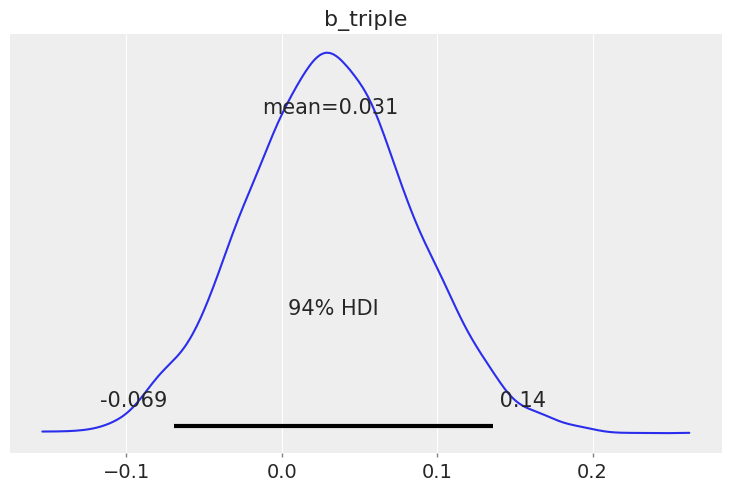

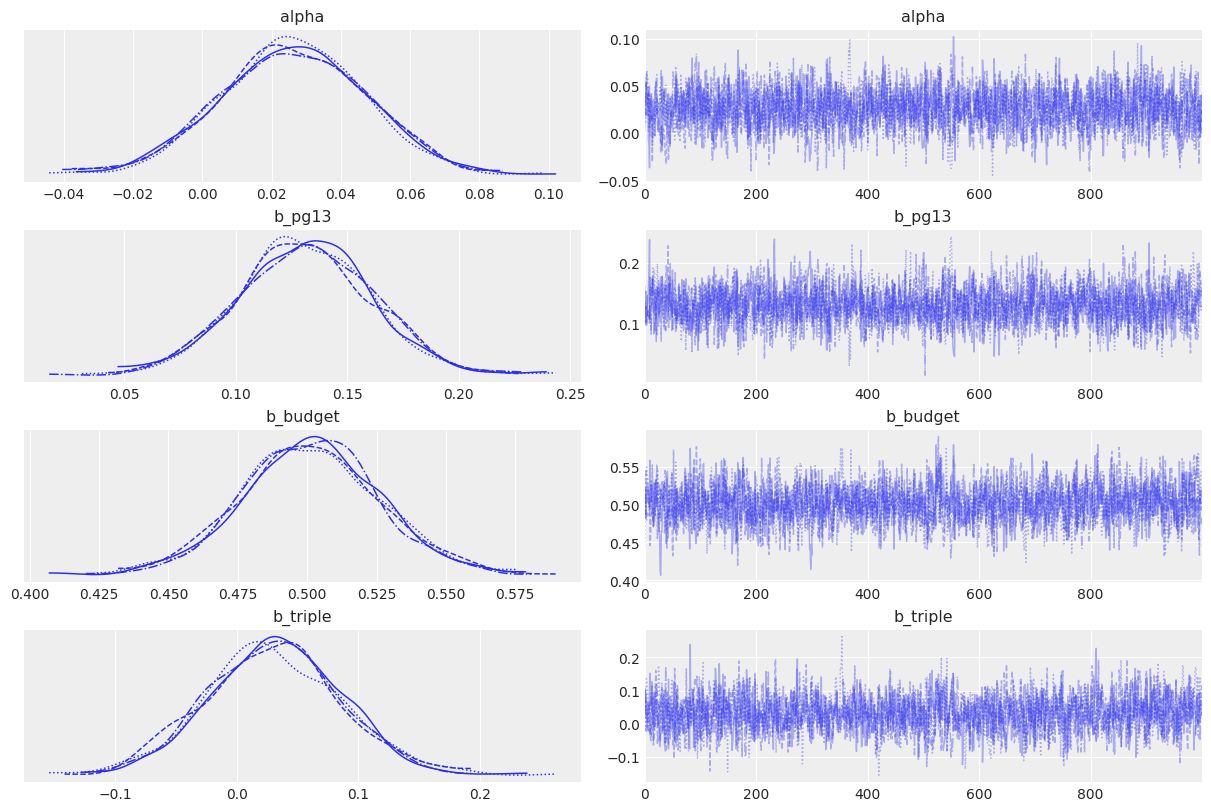

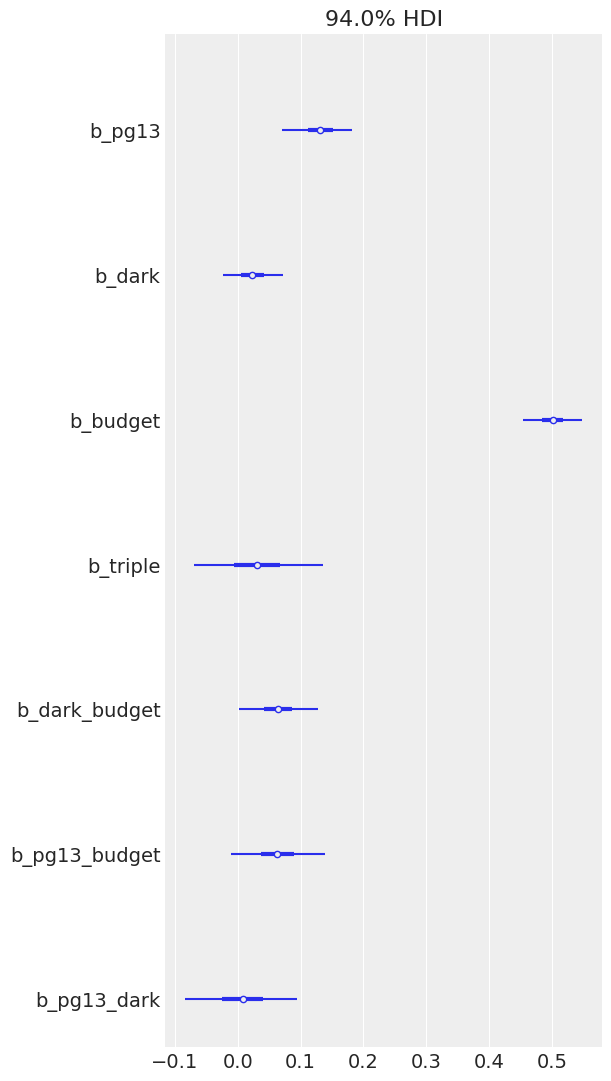

In [24]:
az.plot_posterior(idata_model2_extended_revenue, var_names=['b_triple'])
az.plot_trace(idata_model2_extended_revenue, var_names=['alpha', 'b_pg13', 'b_budget', 'b_triple'])
az.plot_forest(idata_model2_extended_revenue, var_names=['b_pg13', 'b_dark', 'b_budget', 'b_triple','b_dark_budget', 'b_pg13_budget', 'b_pg13_dark'], combined=True, hdi_prob=0.94)

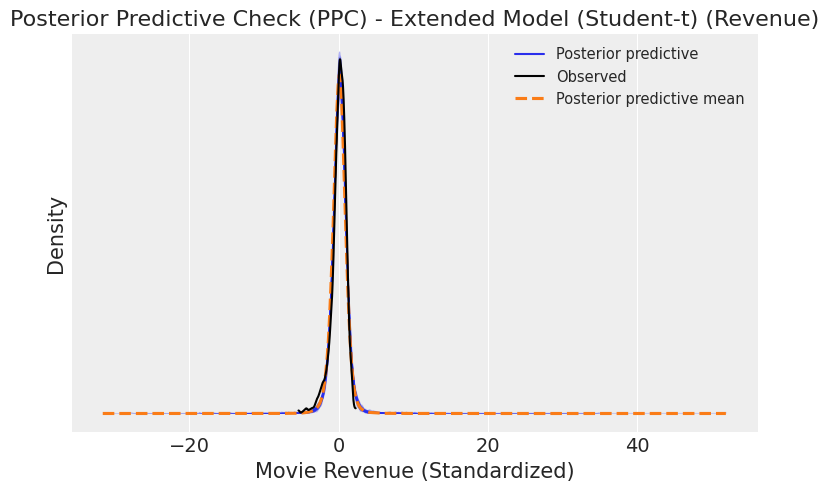

In [25]:
idata_model2_extended_revenue = az.from_cmdstanpy(
    posterior=fit_model2_extended_revenue,
    posterior_predictive="y_rep",
    observed_data={"y": df_clean["std_gross"].values}
)

az.plot_ppc(idata_model2_extended_revenue, data_pairs={"y": "y_rep"}, num_pp_samples=50, kind="kde")

plt.title("Posterior Predictive Check (PPC) - Extended Model (Student-t) (Revenue)")
plt.xlabel("Movie Revenue (Standardized)")
plt.ylabel("Density")
plt.show()

## Model 3 (Hierarchical Rating)

In [26]:
df_clean['primary_genre'] = df_clean['Main Genres'].apply(lambda x: str(x).split(',')[0].strip())
unique_genres = df_clean['primary_genre'].unique()
genre_to_id = {genre: i+1 for i, genre in enumerate(unique_genres)}
df_clean['genre_id'] = df_clean['primary_genre'].map(genre_to_id)
J = len(unique_genres)

hierarchical_data = {
    "N": len(df_clean),
    "J": J,
    "y": df_clean["Rating (Out of 10)"].values,
    "is_pg13": df_clean["is_pg13"].values, 
    "budget": df_clean["std_budget"].values,
    "genre_id": df_clean["genre_id"].values,
    "num_ratings": df_clean["Number of Ratings (in thousands)"].values
}

In [27]:
model_hierarchical = CmdStanModel(stan_file="stan/model_hierarchical_rating.stan")

fit_hierarchical = model_hierarchical.sample(
    data=hierarchical_data,
    iter_sampling=1000,
    iter_warmup=1000,
    chains=4,
    seed=42,
    adapt_delta=0.95
)

genre_names_ordered = [genre for genre, id in sorted(genre_to_id.items(), key=lambda item: item[1])]

idata_hierarchical = az.from_cmdstanpy(
    posterior=fit_hierarchical,
    posterior_predictive="y_rep",
    log_likelihood="log_lik",
    observed_data={"y": hierarchical_data["y"]},
    coords={"genre": genre_names_ordered},
    dims={"beta_pg13": ["genre"], "alpha": ["genre"]}
)

15:47:50 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:48:45 - cmdstanpy - INFO - CmdStan done processing.
15:48:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'model_hierarchical_rating.stan', line 45, column 2 to column 33)
	Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'model_hierarchical_rating.stan', line 45, column 2 to column 33)
	Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'model_hierarchical_rating.stan', line 45, column 2 to column 33)
	Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'model_hierarchical_rating.stan', line 45, column 2 to column 33)
	Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'model_hierarchical_rating.stan', line 45, column 2 to column 33)
	Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'model_hierarchical_rating.stan', line 45, column 2 to column 33)
	Exception

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,7.360,0.161,7.044,7.658,0.005,0.004,921.0,1364.0,1.00
mu_pg13,-0.341,0.117,-0.561,-0.126,0.003,0.003,1254.0,1668.0,1.01
sigma_pg13,0.318,0.132,0.101,0.563,0.004,0.003,1128.0,2195.0,1.00
b_budget,0.044,0.018,0.012,0.079,0.000,0.000,4839.0,2833.0,1.00


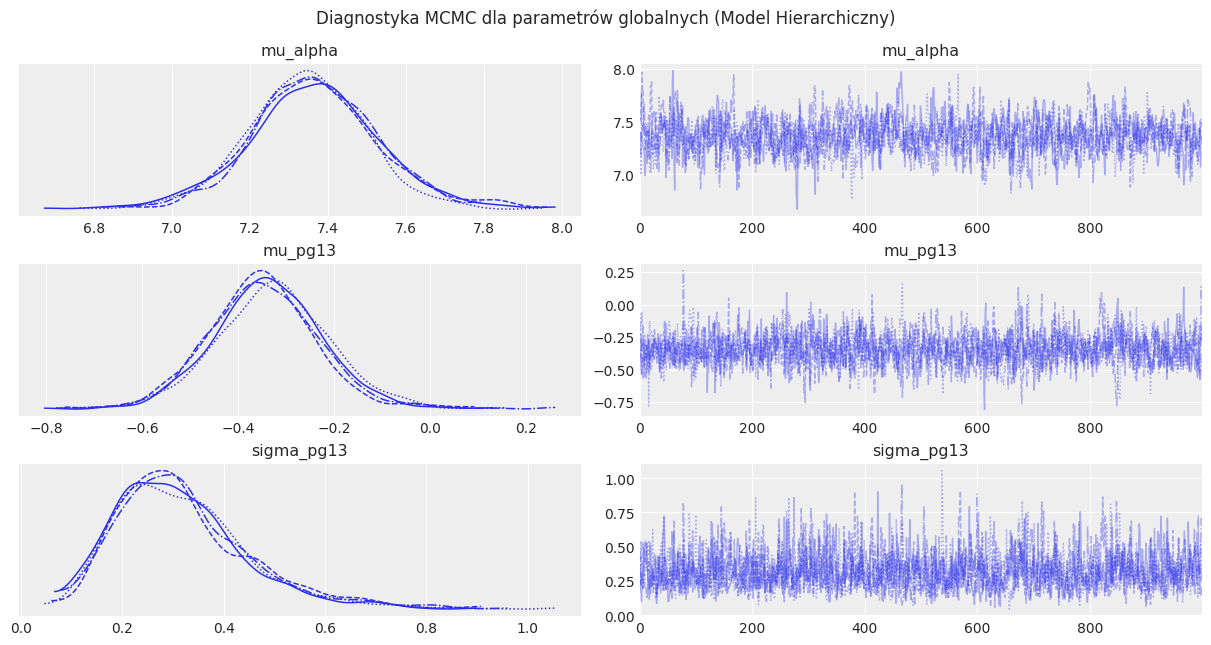

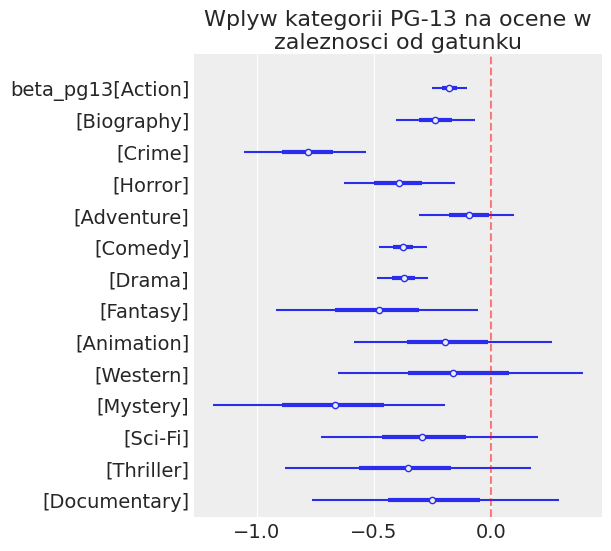

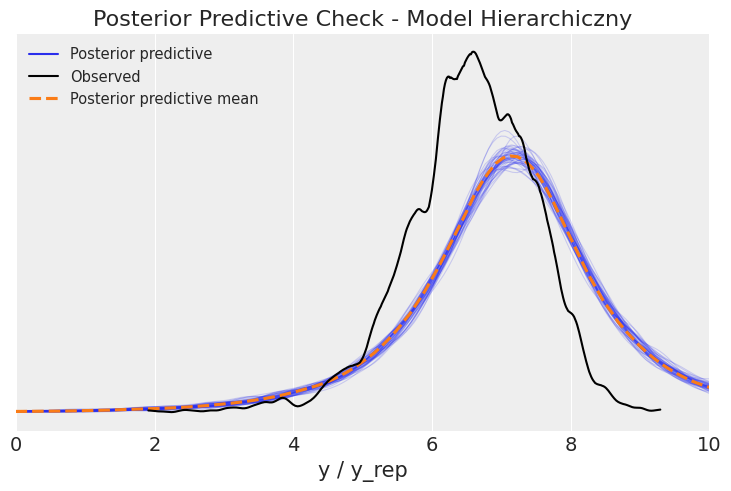

In [28]:
summary_hierarchical = az.summary(idata_hierarchical, var_names=["mu_alpha", "mu_pg13", "sigma_pg13", "b_budget"])
display(summary_hierarchical)

az.plot_trace(idata_hierarchical, var_names=["mu_alpha", "mu_pg13", "sigma_pg13"])
plt.suptitle("Diagnostyka MCMC dla parametrów globalnych (Model Hierarchiczny)", y=1.05)
plt.show()

az.plot_forest(idata_hierarchical, 
               var_names=["beta_pg13"], 
               combined=True, 
               hdi_prob=0.89)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Wplyw kategorii PG-13 na ocene w zaleznosci od gatunku")
plt.show()

az.plot_ppc(idata_hierarchical, data_pairs={"y": "y_rep"}, num_pp_samples=50)
plt.title("Posterior Predictive Check - Model Hierarchiczny")
plt.xlim(0, 10)
plt.show()

In [29]:
df_compare_final = az.compare(
    {"Student-t (Robust)": idata_student_rating,
     "Hierarchical (Genres)": idata_hierarchical},
    ic="loo", 
    scale="deviance"
)
az.plot_compare(df_compare_final)

: 

In [29]:
df_compare_waic = az.compare(
    {"Student-t (Robust)": idata_student_rating, 
     "Hierarchical (Genres)": idata_hierarchical},
    ic="waic", 
    scale="deviance"
)
az.plot_compare(df_compare_waic)

: 